# Przewidywanie zuzycia paliwa w pojazdach (regresja)
---

**Cel projektu:** Przewidzenie zuzycia paliwa w pojazdach na podstawie cech technicznych (moc, masa, liczba cylindrow).

**Zbior danych:** UCI Auto MPG Dataset  
**Link:** https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv

**Algorytmy porownawcze:**
- MLPRegressor - scikit-learn
- RandomForestRegressor - scikit-learn
- SVR - scikit-learn
- KNeighborsRegressor - scikit-learn
- Deep Neural Network - TensorFlow/Keras (GPU)

**Biblioteki:** pandas, seaborn, matplotlib, scikit-learn, tensorflow

---

## Spis treści

1. [Import bibliotek](#1-import-bibliotek)
2. [Wczytanie i eksploracja zbioru danych](#2-wczytanie-i-eksploracja-zbioru-danych)
3. [Rozkłady cech i macierz korelacji](#3-rozklady-cech-i-macierz-korelacji)
4. [Przetwarzanie wstępne danych](#4-przetwarzanie-wstepne-danych)
5. [Metryki jakości modeli](#5-metryki-jakosci-modeli)
6. [Trenowanie modeli](#6-trenowanie-modeli)
   - [6.1 MLPRegressor - GridSearchCV](#61-mlpregressor)
   - [6.2 RandomForestRegressor - GridSearchCV](#62-randomforestregressor)
   - [6.3 SVR](#63-svr)
   - [6.4 KNeighborsRegressor](#64-kneighborsregressor)
   - [6.5 TensorFlow Deep Neural Network (GPU)](#65-tensorflow-dnn)
7. [Porównanie modeli](#7-porownanie-modeli)
8. [Wykresy porównawcze](#8-wykresy-porownawcze)
9. [Błędy względne](#9-bledy-wzgledne)
10. [Dokładność w zależności od typu samochodu](#10-dokladnosc-w-zaleznosci-od-typu-samochodu)
11. [Ranking porownawczy modeli](#11-ranking-porownawczy-modeli)
12. [Przykładowa predykcja najlepszego modelu](#12-przykladowa-predykcja)
---


## 1. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print('Wersje bibliotek:')
print(f'NumPy: {np.__version__}')
print(f'Pandas: {pd.__version__}')
print(f'Scikit-learn: {__import__("sklearn").__version__}')
print(f'TensorFlow: {tf.__version__}')
print(f'Dostepnosc GPU: {len(tf.config.list_physical_devices("GPU")) > 0}')

Wersje bibliotek:
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
TensorFlow: 2.20.0
Dostepnosc GPU: True


## 2. Wczytanie i eksploracja zbioru danych

In [2]:
url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv'
df = pd.read_csv(url)

print('PODSTAWOWE INFORMACJE O ZBIORZE DANYCH')
print(f'Liczba rekordow: {df.shape[0]}')
print(f'Liczba atrybutow: {df.shape[1]}')
print(f'\nBrakujace wartosci:')
print(df.isnull().sum())

print('\nPIERWSZYCH 5 REKORDOW:')
display(df.head())

print('\nSTATYSTYKI OPISOWE:')
display(df.describe())

PODSTAWOWE INFORMACJE O ZBIORZE DANYCH
Liczba rekordow: 398
Liczba atrybutow: 9

Brakujace wartosci:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

PIERWSZYCH 5 REKORDOW:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino



STATYSTYKI OPISOWE:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


## 3. Rozklady cech i macierz korelacji

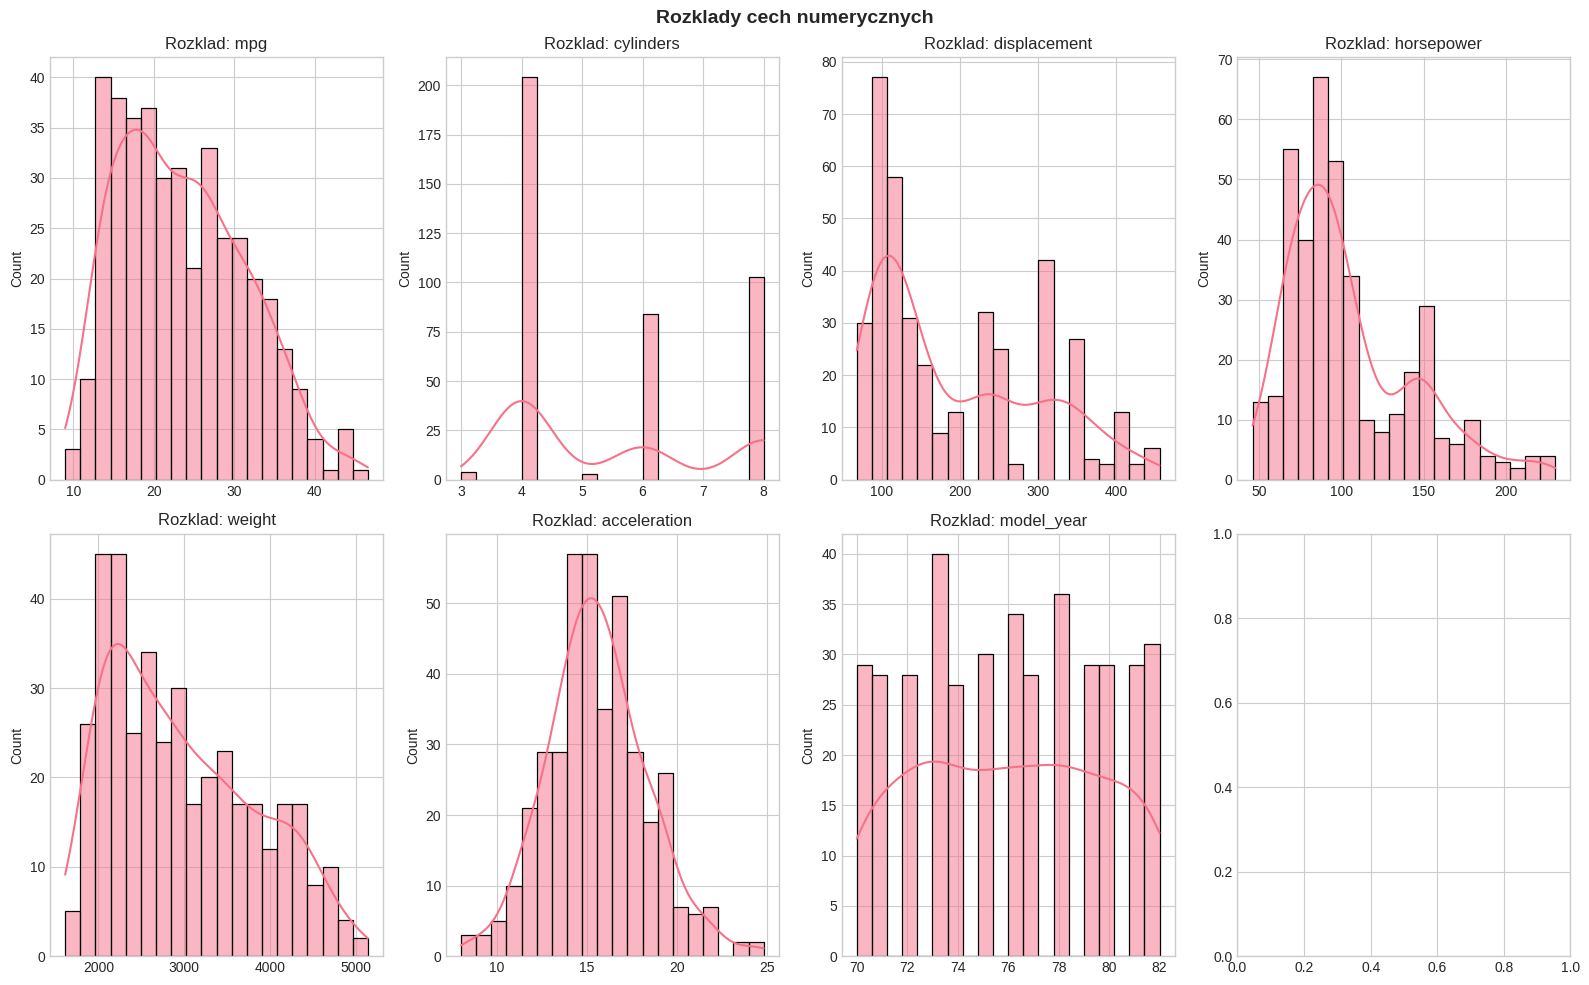


Rozklad atrybutu origin (kraj pochodzenia):
origin
europe     70
japan      79
usa       249
Name: count, dtype: int64


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle('Rozklady cech numerycznych', fontsize=14, fontweight='bold')

numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year']

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 4, idx % 4]
    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=20)
    ax.set_title(f'Rozklad: {col}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

print('\nRozklad atrybutu origin (kraj pochodzenia):')
print(df['origin'].value_counts().sort_index())

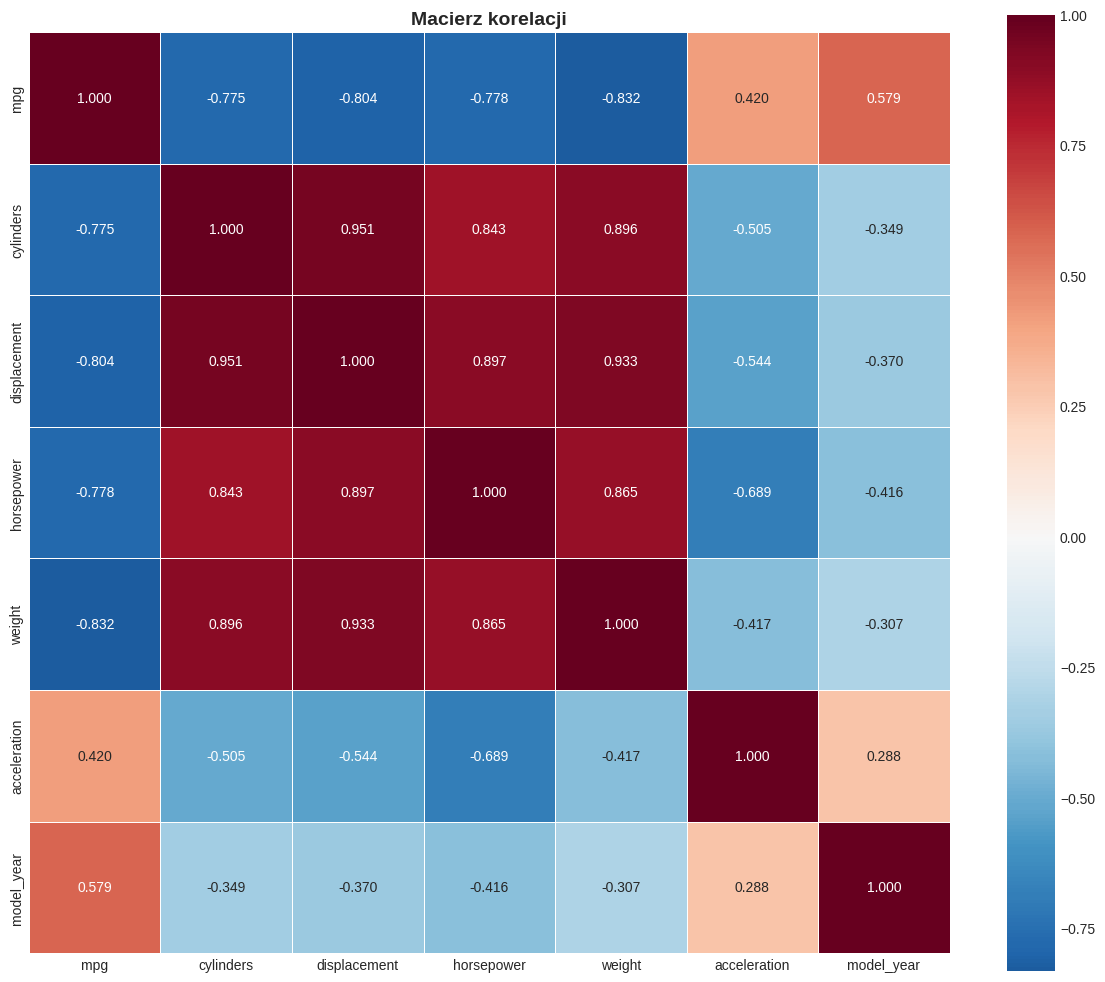


Korelacje z mpg:
mpg             1.000000
model_year      0.579267
acceleration    0.420289
cylinders      -0.775396
horsepower     -0.778427
displacement   -0.804203
weight         -0.831741
Name: mpg, dtype: float64


In [4]:
plt.figure(figsize=(12, 10))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0,
            fmt='.3f', square=True, linewidths=0.5)
plt.title('Macierz korelacji', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nKorelacje z mpg:')
print(correlation_matrix['mpg'].sort_values(ascending=False))

## 4. Przetwarzanie wstepne danych

In [5]:
df_clean = df.copy()

print(f'Rekordy z NaN: {df_clean.isnull().sum().sum()}')
df_clean = df_clean.dropna()
print(f'Rekordy po usunieciu NaN: {len(df_clean)}')

print('\nUsuwanie wartości odstających (metoda IQR):')
numeric_cols = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
initial_count = len(df_clean)

for col in numeric_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_before = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    if outliers_before > 0:
        print(f'  {col}: {outliers_before} wartości odstających (zakres: {lower_bound:.2f} - {upper_bound:.2f})')
    df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

print(f'\nRekordy po usunięciu outlierów: {len(df_clean)} (usunięto: {initial_count - len(df_clean)})')

def extract_car_type(name):
    name_lower = str(name).lower()
    if any(x in name_lower for x in ['ford', 'chevrolet', 'plymouth', 'dodge', 'amc', 'buick', 'chrysler', 'pontiac', 'oldsmobile', 'mercury', 'cadillac', 'lincoln']):
        return 'amerykanski'
    elif any(x in name_lower for x in ['vw', 'volkswagen', 'bmw', 'audi', 'opel', 'peugeot', 'renault', 'volvo', 'saab', 'fiat']):
        return 'europejski'
    elif any(x in name_lower for x in ['toyota', 'honda', 'datsun', 'mazda', 'subaru', 'nissan', 'mitsubishi']):
        return 'japonski'
    else:
        return 'inny'

df_clean['car_type'] = df_clean['name'].apply(extract_car_type)

print('\nRozklad typow pojazdow:')
print(df_clean['car_type'].value_counts())

df_clean['origin'] = df_clean['origin'].astype(str)
origin_dummies = pd.get_dummies(df_clean['origin'], prefix='origin', dtype=int)
df_processed = pd.concat([df_clean, origin_dummies], axis=1)

origin_cols = [col for col in df_processed.columns if col.startswith('origin_')]
feature_columns = ['cylinders', 'displacement', 'horsepower', 'weight',
                   'acceleration', 'model_year'] + origin_cols

X = df_processed[feature_columns].values
y = df_processed['mpg'].values
car_types_all = df_processed['car_type'].values

X_train, X_test, y_train, y_test, car_type_train, car_type_test = train_test_split(
    X, y, car_types_all, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nX_train: {X_train_scaled.shape}, X_test: {X_test_scaled.shape}')

Rekordy z NaN: 6
Rekordy po usunieciu NaN: 392

Usuwanie wartości odstających (metoda IQR):
  horsepower: 10 wartości odstających (zakres: -1.50 - 202.50)
  acceleration: 9 wartości odstających (zakres: 9.20 - 22.00)

Rekordy po usunięciu outlierów: 373 (usunięto: 19)

Rozklad typow pojazdow:
car_type
amerykanski    224
japonski        76
europejski      59
inny            14
Name: count, dtype: int64

X_train: (298, 9), X_test: (75, 9)


## 5. Definicja metryk jakosci

In [6]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = {}
predictions = {}

## 6. Trenowanie modeli


### 6.1 MLPRegressor - GridSearchCV


In [7]:
print('OPTYMALIZACJA - MLPRegressor (GridSearchCV)')

mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01]
}

mlp_base = MLPRegressor(max_iter=1000, random_state=42, early_stopping=True)

mlp_grid = GridSearchCV(
    estimator=mlp_base,
    param_grid=mlp_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

mlp_grid.fit(X_train_scaled, y_train)

print(f'\nNajlepsze parametry:')
for param, value in mlp_grid.best_params_.items():
    print(f'  {param}: {value}')

mlp_best = mlp_grid.best_estimator_
y_pred_mlp = mlp_best.predict(X_test_scaled)
results['MLPRegressor'] = calculate_metrics(y_test, y_pred_mlp)
predictions['MLPRegressor'] = y_pred_mlp

print(f'\nMetryki testowe:')
for metric, value in results['MLPRegressor'].items():
    print(f'  {metric}: {value:.4f}')

OPTYMALIZACJA - MLPRegressor (GridSearchCV)
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Najlepsze parametry:
  activation: relu
  alpha: 0.01
  hidden_layer_sizes: (100, 50)
  learning_rate_init: 0.01

Metryki testowe:
  MAE: 1.9968
  MSE: 6.9128
  RMSE: 2.6292
  R2: 0.8787
  MAPE: 8.1411


### 6.2 RandomForestRegressor - GridSearchCV


In [8]:
print('OPTYMALIZACJA - RandomForestRegressor (GridSearchCV)')

rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f'\nNajlepsze parametry:')
for param, value in rf_grid.best_params_.items():
    print(f'  {param}: {value}')

rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict(X_test)
results['RandomForest'] = calculate_metrics(y_test, y_pred_rf)
predictions['RandomForest'] = y_pred_rf

print(f'\nMetryki testowe:')
for metric, value in results['RandomForest'].items():
    print(f'  {metric}: {value:.4f}')

print('\nWaznosc cech (Random Forest):')
feature_importance = pd.DataFrame({
    'Cecha': feature_columns,
    'Waznosc': rf_best.feature_importances_
}).sort_values('Waznosc', ascending=False)
print(feature_importance.to_string(index=False))

OPTYMALIZACJA - RandomForestRegressor (GridSearchCV)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Najlepsze parametry:
  max_depth: None
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 300

Metryki testowe:
  MAE: 1.8010
  MSE: 5.9590
  RMSE: 2.4411
  R2: 0.8954
  MAPE: 7.5756

Waznosc cech (Random Forest):
        Cecha  Waznosc
 displacement 0.358115
       weight 0.228832
   horsepower 0.181612
   model_year 0.132454
    cylinders 0.073386
 acceleration 0.019068
 origin_japan 0.003874
   origin_usa 0.001566
origin_europe 0.001092


### 6.3 SVR


In [9]:
print('TRENOWANIE - SVR')

svr_model = SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale')
svr_model.fit(X_train_scaled, y_train)

y_pred_svr = svr_model.predict(X_test_scaled)
results['SVR'] = calculate_metrics(y_test, y_pred_svr)
predictions['SVR'] = y_pred_svr

print(f'Metryki testowe:')
for metric, value in results['SVR'].items():
    print(f'  {metric}: {value:.4f}')


TRENOWANIE - SVR
Metryki testowe:
  MAE: 1.7703
  MSE: 5.7385
  RMSE: 2.3955
  R2: 0.8993
  MAPE: 7.2413


### 6.4 KNeighborsRegressor


In [10]:
print('TRENOWANIE - KNeighborsRegressor')

knn_model = KNeighborsRegressor(n_neighbors=5, weights='distance', metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
results['KNeighbors'] = calculate_metrics(y_test, y_pred_knn)
predictions['KNeighbors'] = y_pred_knn

print(f'Metryki testowe:')
for metric, value in results['KNeighbors'].items():
    print(f'  {metric}: {value:.4f}')


TRENOWANIE - KNeighborsRegressor
Metryki testowe:
  MAE: 1.9509
  MSE: 6.5813
  RMSE: 2.5654
  R2: 0.8845
  MAPE: 8.0780


### 6.5 TensorFlow Deep Neural Network (GPU)


In [11]:
print('TRENOWANIE - TensorFlow DNN (GPU)')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6
)

tf_model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

tf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

tf_model.summary()

history = tf_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

y_pred_tf = tf_model.predict(X_test_scaled).flatten()
results['TensorFlow_DNN'] = calculate_metrics(y_test, y_pred_tf)
predictions['TensorFlow_DNN'] = y_pred_tf

print(f'\nMetryki testowe:')
for metric, value in results['TensorFlow_DNN'].items():
    print(f'  {metric}: {value:.4f}')

TRENOWANIE - TensorFlow DNN (GPU)
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 403ms/step - loss: 541.3318 - mae: 22.2174 - val_loss: 571.4556 - val_mae: 22.6709 - learning_rate: 0.0010
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 481.1295 - mae: 21.1076 - val_loss: 550.2530 - val_mae: 22.2986 - learning_rate: 0.0010
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 427.5890 - mae: 19.9814 - val_loss: 526.0831 - val_mae: 21.8638 - learning_rate: 0.0010
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 379.6200 - mae: 18.8363 - val_loss: 497.9247 - val_mae: 21.3362 - learning_rate: 0.0010
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 340.2041 - mae: 17.7743 - val_loss: 465.3115 - val_mae: 20.6868 - learning_rate: 0.0010
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 289.8893 - mae: 16.4401 - val_loss: 428.4156 - val_mae: 19.9163 - learning_rate: 0.0010
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 250.1299 - mae: 15.1651 - val_loss: 389.4676 - val_mae: 19.0571 -

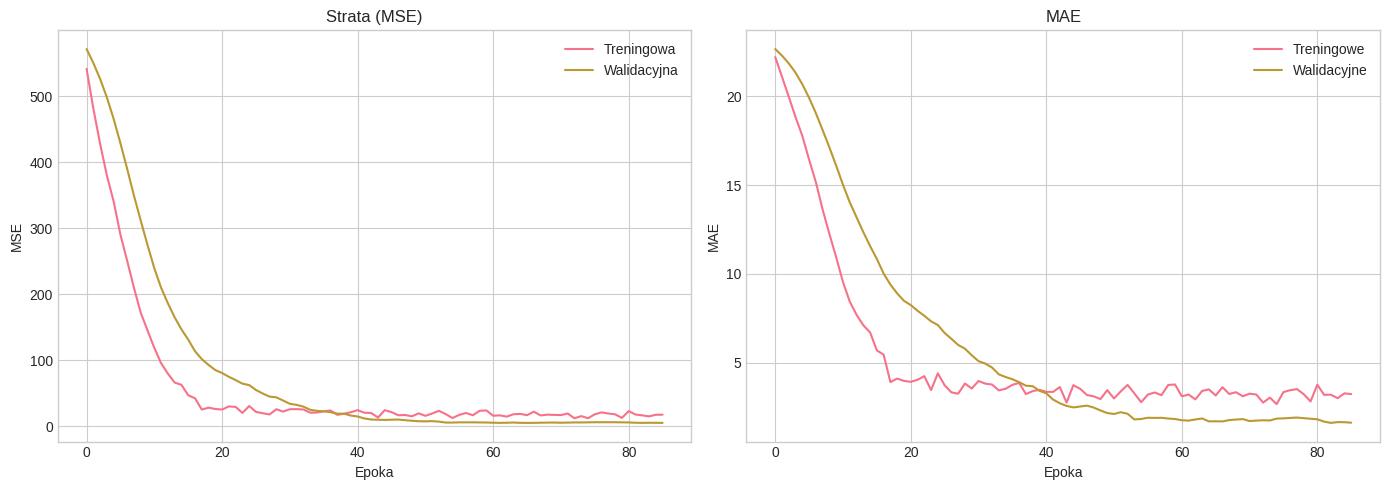

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Treningowa')
axes[0].plot(history.history['val_loss'], label='Walidacyjna')
axes[0].set_title('Strata (MSE)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['mae'], label='Treningowe')
axes[1].plot(history.history['val_mae'], label='Walidacyjne')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 7. Porównanie modeli


In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df[['MAE', 'MSE', 'RMSE', 'R2', 'MAPE']]

print('POROWNANIE MODELI')
display(results_df.style.format('{:.4f}').highlight_min(color='lightgreen'))

print('\nRanking (R2):')
ranking = results_df['R2'].sort_values(ascending=False)
for i, (model, score) in enumerate(ranking.items(), 1):
    print(f'  {i}. {model}: R2 = {score:.4f}')

POROWNANIE MODELI


,MAE,MSE,RMSE,R2,MAPE
MLPRegressor,1.9968,6.9128,2.6292,0.8787,8.1411
RandomForest,1.8010,5.9590,2.4411,0.8954,7.5756
SVR,1.7703,5.7385,2.3955,0.8993,7.2413
KNeighbors,1.9509,6.5813,2.5654,0.8845,8.0780
TensorFlow_DNN,2.1636,7.4356,2.7268,0.8695,9.3605



Ranking (R2):
  1. SVR: R2 = 0.8993
  2. RandomForest: R2 = 0.8954
  3. KNeighbors: R2 = 0.8845
  4. MLPRegressor: R2 = 0.8787
  5. TensorFlow_DNN: R2 = 0.8695


## 8. Wykresy porównawcze


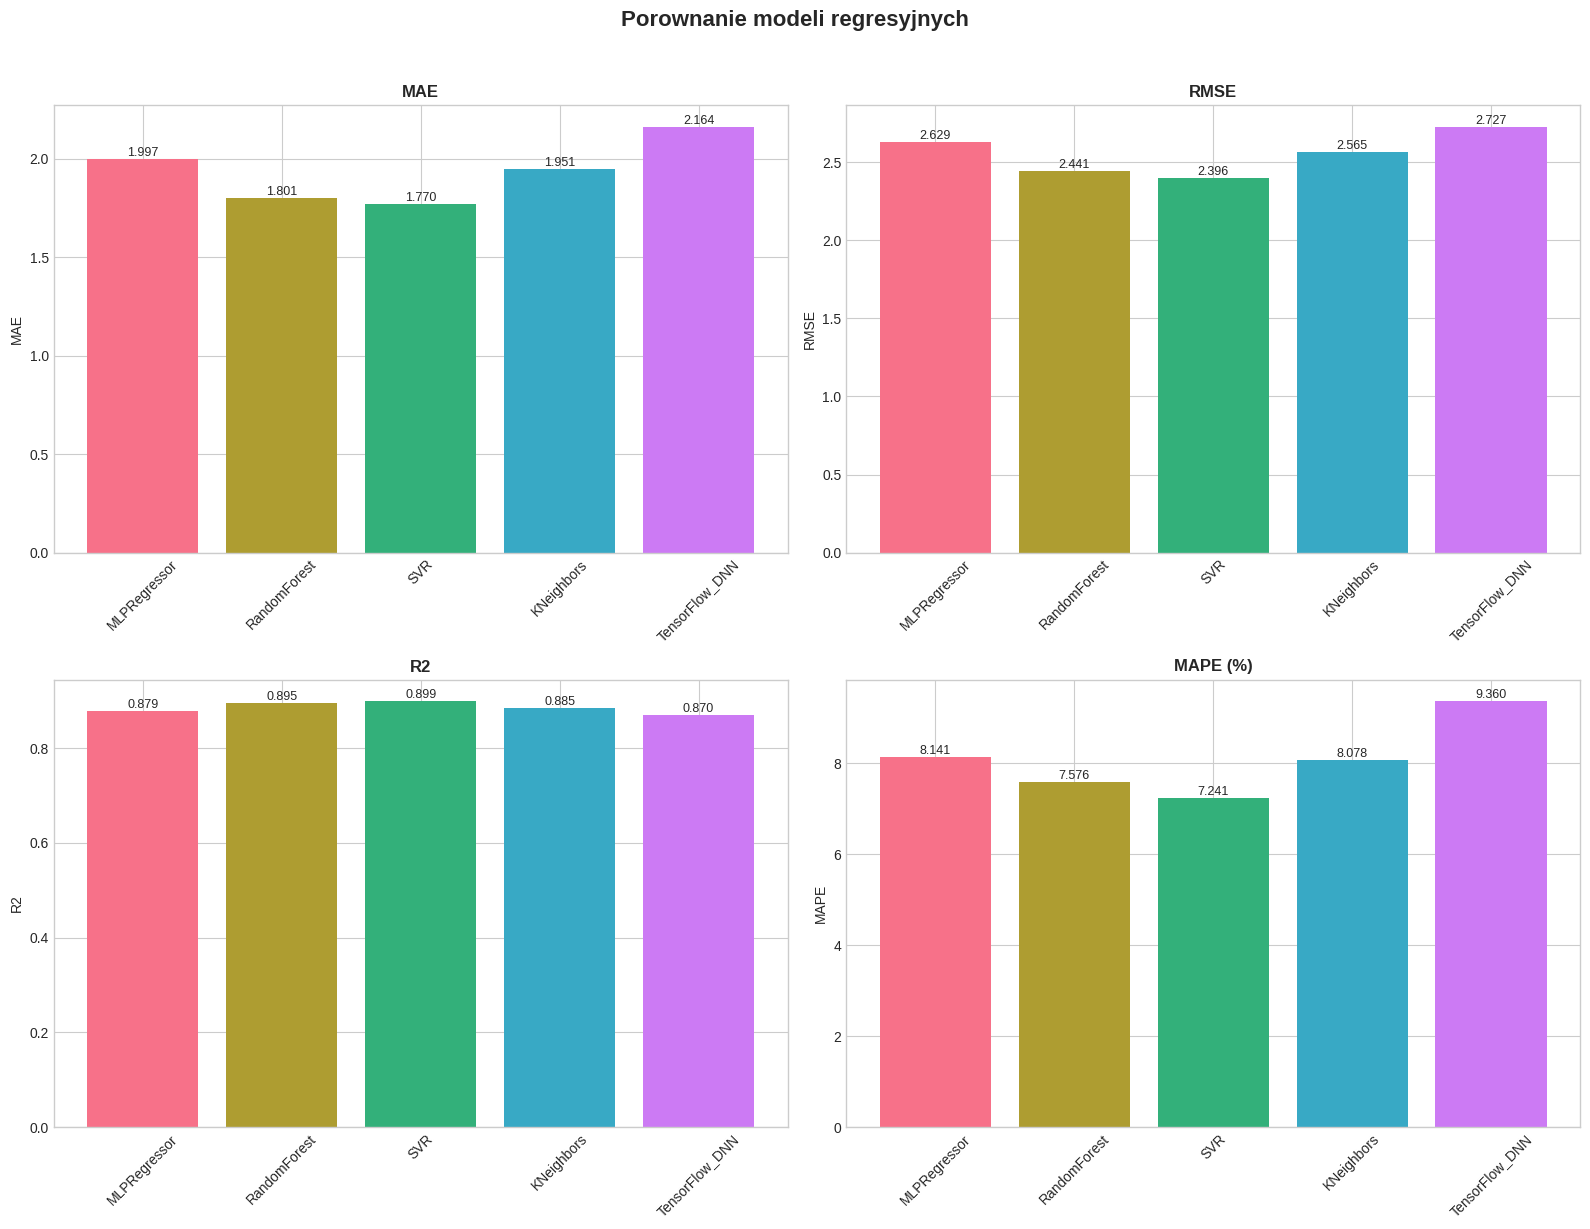

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['MAE', 'RMSE', 'R2', 'MAPE']
titles = ['MAE', 'RMSE', 'R2', 'MAPE (%)']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, titles)):
    ax = axes[idx // 2, idx % 2]
    colors = sns.color_palette('husl', len(results))
    bars = ax.bar(results_df.index, results_df[metric], color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)

    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Porownanie modeli regresyjnych', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

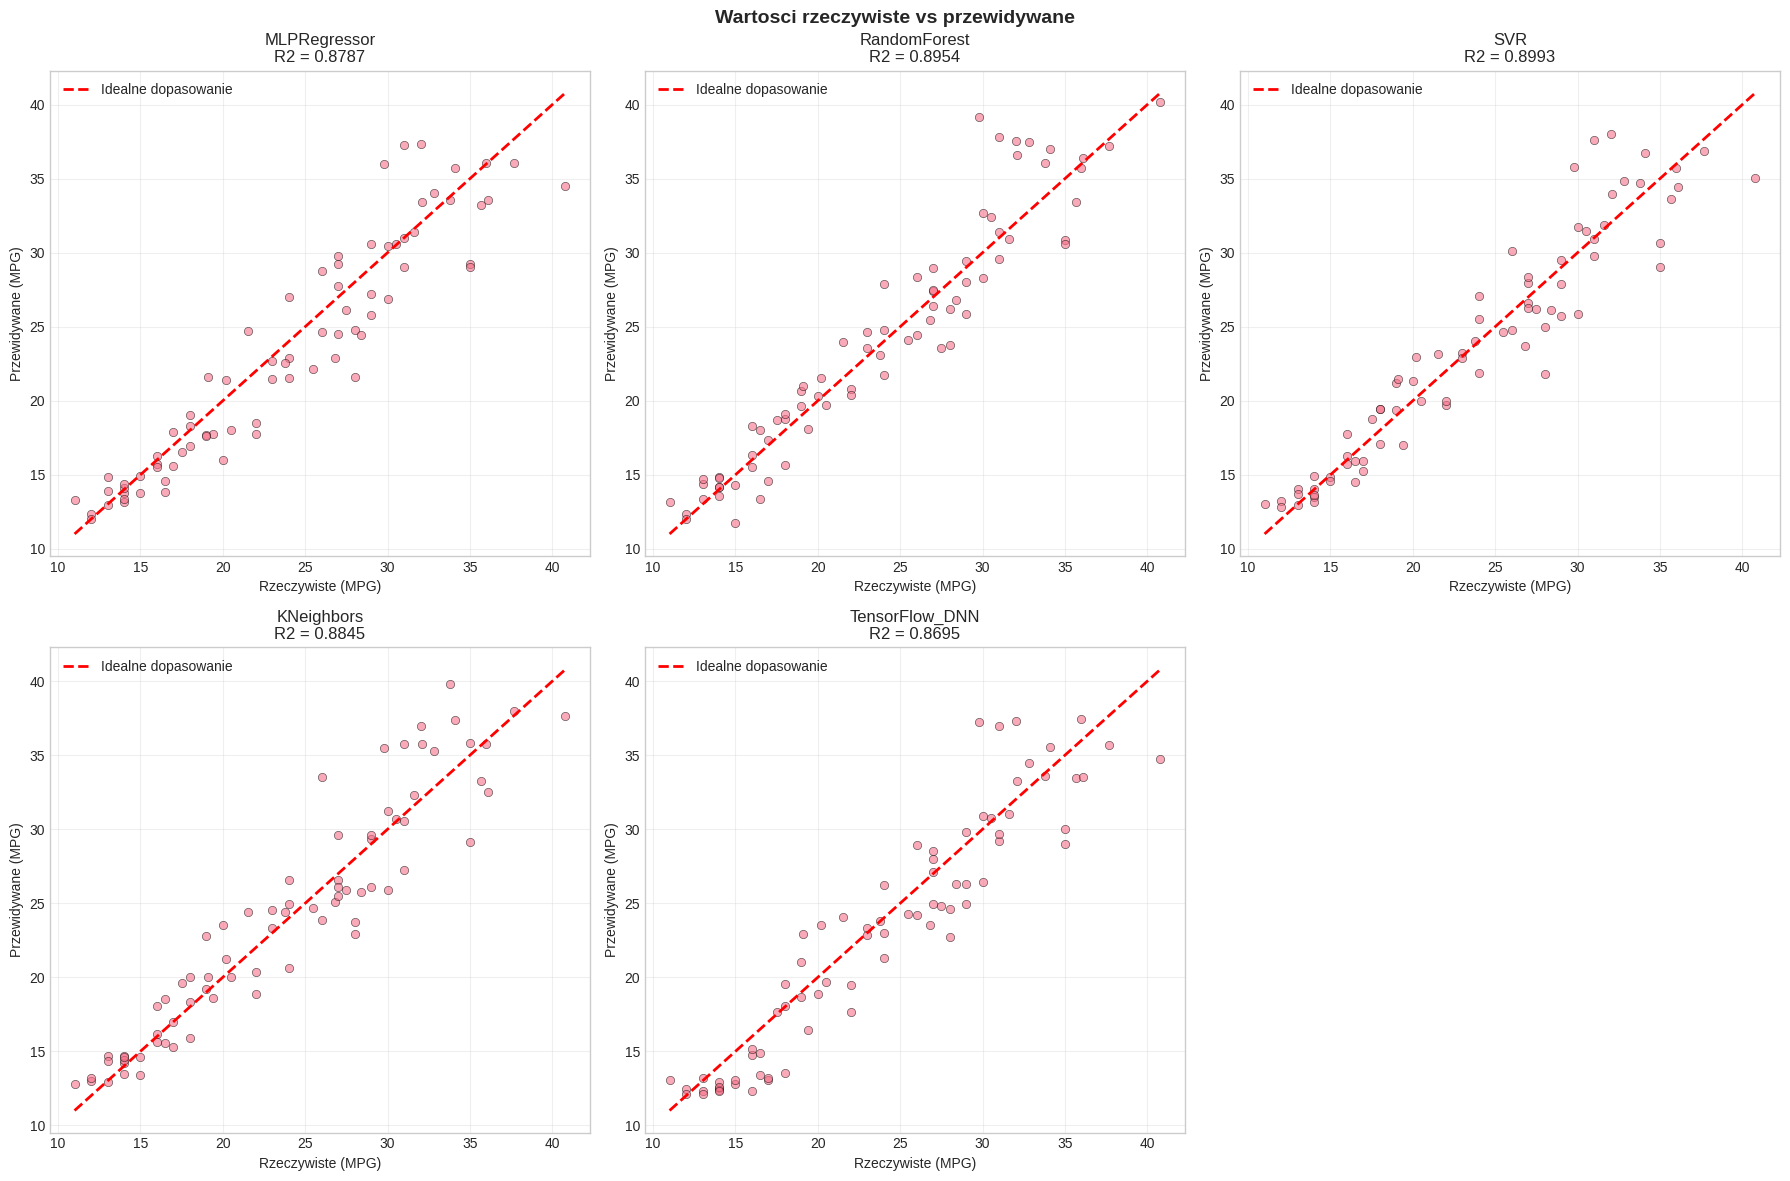

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    ax.scatter(y_test, y_pred, alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
            'r--', linewidth=2, label='Idealne dopasowanie')
    ax.set_xlabel('Rzeczywiste (MPG)')
    ax.set_ylabel('Przewidywane (MPG)')
    ax.set_title(f'{model_name}\nR2 = {results[model_name]["R2"]:.4f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Wartosci rzeczywiste vs przewidywane', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Błędy względne


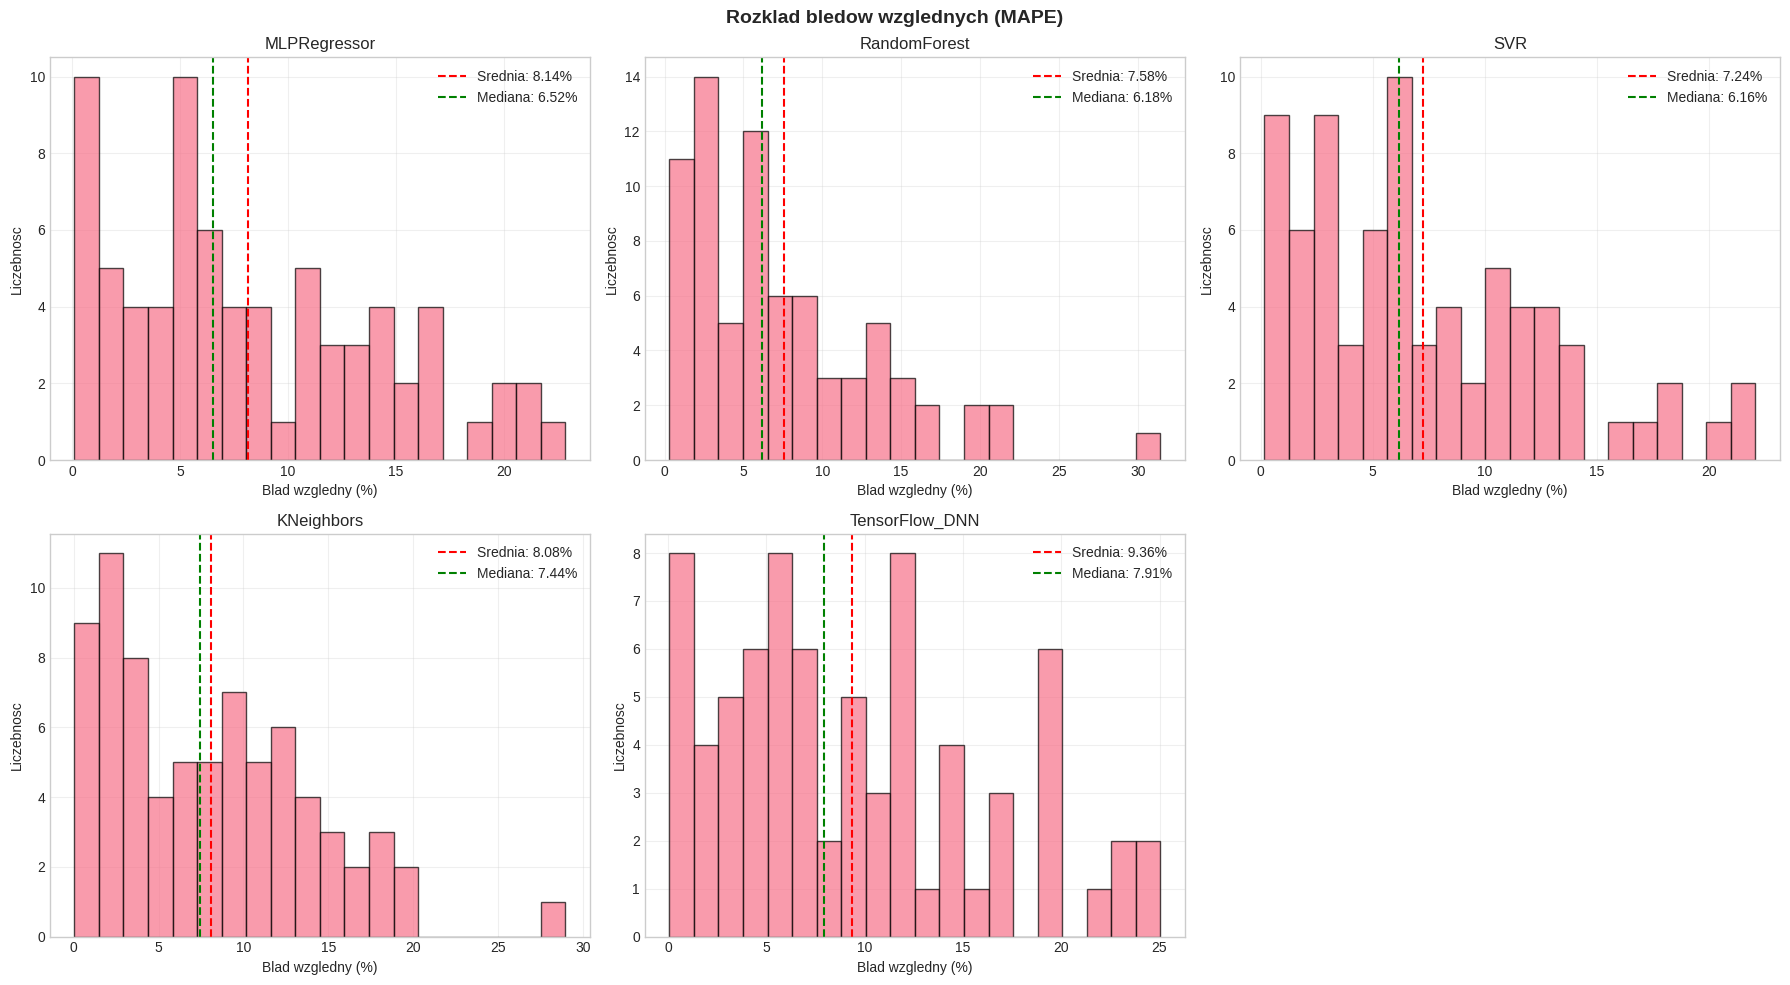


Statystyki bledow wzglednych (%):


,MLPRegressor,RandomForest,SVR,KNeighbors,TensorFlow_DNN
count,75.00,75.00,75.00,75.00,75.00
mean,8.14,7.58,7.24,8.08,9.36
std,6.07,6.08,5.47,6.00,6.70
min,0.11,0.31,0.17,0.05,0.06
25%,3.48,3.05,2.74,2.57,4.11
50%,6.52,6.18,6.16,7.44,7.91
75%,12.40,10.71,10.92,12.12,13.49
max,22.85,31.44,22.09,28.94,25.04


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx]
    errors = np.abs((y_test - y_pred) / y_test) * 100
    ax.hist(errors, bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(errors), color='red', linestyle='--',
               label=f'Srednia: {np.mean(errors):.2f}%')
    ax.axvline(np.median(errors), color='green', linestyle='--',
               label=f'Mediana: {np.median(errors):.2f}%')
    ax.set_xlabel('Blad wzgledny (%)')
    ax.set_ylabel('Liczebnosc')
    ax.set_title(f'{model_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')

plt.suptitle('Rozklad bledow wzglednych (MAPE)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nStatystyki bledow wzglednych (%):')
error_stats = pd.DataFrame()
for model_name, y_pred in predictions.items():
    errors = np.abs((y_test - y_pred) / y_test) * 100
    error_stats[model_name] = errors

display(error_stats.describe().round(2))

## 10. Dokładność w zależności od typu samochodu


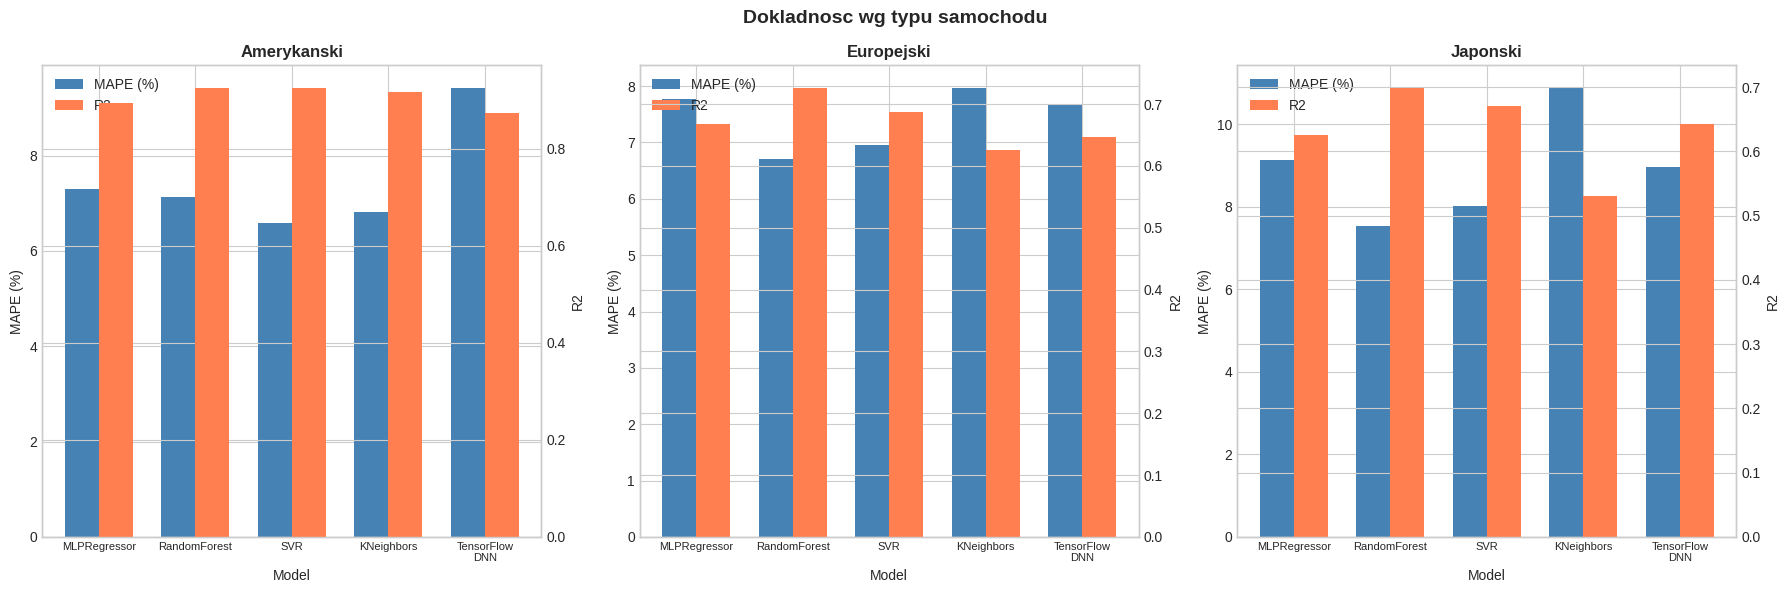


Wyniki wedlug typu:

--- AMERYKANSKI ---


,MAE,R2,MAPE
MLPRegressor,1.529,0.893,7.304
RandomForest,1.423,0.924,7.128
SVR,1.337,0.925,6.594
KNeighbors,1.400,0.917,6.827
TensorFlow_DNN,1.794,0.873,9.423



--- EUROPEJSKI ---


,MAE,R2,MAPE
MLPRegressor,1.997,0.668,7.776
RandomForest,1.703,0.726,6.705
SVR,1.821,0.687,6.956
KNeighbors,2.053,0.626,7.971
TensorFlow_DNN,2.034,0.647,7.687



--- JAPONSKI ---


,MAE,R2,MAPE
MLPRegressor,2.773,0.626,9.140
RandomForest,2.294,0.699,7.527
SVR,2.466,0.670,8.021
KNeighbors,3.187,0.530,10.880
TensorFlow_DNN,2.774,0.642,8.953


In [17]:
car_types = ['amerykanski', 'europejski', 'japonski']
type_results = {ct: {} for ct in car_types}

for model_name, y_pred in predictions.items():
    for car_type in car_types:
        mask = car_type_test == car_type
        if mask.sum() > 0:
            metrics = calculate_metrics(y_test[mask], y_pred[mask])
            type_results[car_type][model_name] = metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, car_type in enumerate(car_types):
    ax = axes[idx]
    model_names = list(type_results[car_type].keys())
    mape_values = [type_results[car_type][m]['MAPE'] for m in model_names]
    r2_values = [type_results[car_type][m]['R2'] for m in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    bars1 = ax.bar(x - width/2, mape_values, width, label='MAPE (%)', color='steelblue')
    ax2 = ax.twinx()
    bars2 = ax2.bar(x + width/2, r2_values, width, label='R2', color='coral')

    ax.set_xlabel('Model')
    ax.set_ylabel('MAPE (%)')
    ax2.set_ylabel('R2')
    ax.set_title(f'{car_type.capitalize()}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', '\n') for m in model_names], fontsize=8)

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle('Dokladnosc wg typu samochodu', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nWyniki wedlug typu:')
for car_type in car_types:
    print(f'\n--- {car_type.upper()} ---')
    type_df = pd.DataFrame(type_results[car_type]).T
    display(type_df[['MAE', 'R2', 'MAPE']].round(3))

## 11. Ranking porownawczy modeli


In [18]:
print('PODSUMOWANIE')

final_results = results_df.copy()
final_results['Ranking'] = final_results['R2'].rank(ascending=False).astype(int)
final_results = final_results.sort_values('Ranking')

display(final_results.style.format({
    'MAE': '{:.4f}',
    'MSE': '{:.4f}',
    'RMSE': '{:.4f}',
    'R2': '{:.4f}',
    'MAPE': '{:.2f}%'
}).highlight_min(subset=['MAE', 'MSE', 'RMSE', 'MAPE'], color='lightgreen')
 .highlight_max(subset=['R2'], color='lightgreen'))

best_model = final_results.index[0]
print(f'\nNajlepszy model: {best_model}')
print(f'  R2 = {final_results.loc[best_model, "R2"]:.4f}')
print(f'  MAE = {final_results.loc[best_model, "MAE"]:.4f} MPG')
print(f'  MAPE = {final_results.loc[best_model, "MAPE"]:.2f}%')

PODSUMOWANIE


,MAE,MSE,RMSE,R2,MAPE,Ranking
SVR,1.7703,5.7385,2.3955,0.8993,7.24%,1
RandomForest,1.8010,5.9590,2.4411,0.8954,7.58%,2
KNeighbors,1.9509,6.5813,2.5654,0.8845,8.08%,3
MLPRegressor,1.9968,6.9128,2.6292,0.8787,8.14%,4
TensorFlow_DNN,2.1636,7.4356,2.7268,0.8695,9.36%,5



Najlepszy model: SVR
  R2 = 0.8993
  MAE = 1.7703 MPG
  MAPE = 7.24%


## 12. Przykładowa predykcja najlepszego modelu


In [40]:
print('PRZYKŁADOWA PREDYKCJA DLA NAJLEPSZEGO MODELU')
print('='*60)

random_idx = np.random.randint(0, len(X_test))
X_sample = X_test[random_idx:random_idx+1]
X_sample_scaled = X_test_scaled[random_idx:random_idx+1]
y_actual = y_test[random_idx]

cylinders = int(X_sample[0][0])
displacement = X_sample[0][1]
horsepower = X_sample[0][2]
weight = X_sample[0][3]
acceleration = X_sample[0][4]
model_year = int(X_sample[0][5])
origin_usa = int(X_sample[0][6])
origin_europe = int(X_sample[0][7])
origin_japan = int(X_sample[0][8])

predicted_mpg = svr_model.predict(X_sample_scaled)[0]

print(f'\nLosowo wybrany pojazd ze zbioru testowego')
print(f'Indeks w zbiorze testowym: {random_idx}')
print(f'\nDane wejściowe:')
print(f'  - Cylindry: {cylinders}')
print(f'  - Pojemność: {displacement} cal³')
print(f'  - Moc: {horsepower} KM')
print(f'  - Masa: {weight} funtów')
print(f'  - Przyspieszenie: {acceleration} s')
print(f'  - Rok modelu: {model_year} ({1900+model_year})')
if origin_usa == 1:
    print(f'  - Pochodzenie: USA')
elif origin_europe == 1:
    print(f'  - Pochodzenie: Europa')
elif origin_japan == 1:
    print(f'  - Pochodzenie: Japonia')
print(f'\nRZECZYWISTE ZUŻYCIE PALIWA: {y_actual:.2f} MPG')
print(f'PRZEWIDYWANE ZUŻYCIE PALIWA: {predicted_mpg:.2f} MPG')
print(f'\nBŁĄD: {abs(y_actual - predicted_mpg):.2f} MPG ({abs((y_actual - predicted_mpg)/y_actual)*100:.2f}%)')

PRZYKŁADOWA PREDYKCJA DLA NAJLEPSZEGO MODELU

Losowo wybrany pojazd ze zbioru testowego
Indeks w zbiorze testowym: 38

Dane wejściowe:
  - Cylindry: 4
  - Pojemność: 97.0 cal³
  - Moc: 75.0 KM
  - Masa: 2171.0 funtów
  - Przyspieszenie: 16.0 s
  - Rok modelu: 75 (1975)
  - Pochodzenie: Europa

RZECZYWISTE ZUŻYCIE PALIWA: 29.00 MPG
PRZEWIDYWANE ZUŻYCIE PALIWA: 27.87 MPG

BŁĄD: 1.13 MPG (3.91%)
